In [6]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


In [7]:

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()



In [9]:

# Load dataset
path = "/content/Resume-final-v3.csv"

In [10]:

df = pd.read_csv(path).dropna()  # Remove empty rows


In [11]:
######################################################
if 'index' not in df.columns:
    df.insert(0, 'index', range(1, len(df) + 1))
else:
    print("Column 'index' already exists in the DataFrame.")
##############################################################


In [12]:
# Convert text to lowercase
df['Resume'] = df['Resume'].str.lower()



In [13]:


# Remove duplicates
df.drop_duplicates(inplace=True)


In [14]:

# Define stop words
stop_words = set(stopwords.words('english'))


In [15]:

# Text preprocessing function (before tokenization)
def preprocess_text(text):
    if isinstance(text, str):
        text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters, keep letters and spaces
        text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
        text = re.sub('http\S+\s*', ' ', text)  # remove URLs
        text = re.sub('RT|cc', ' ', text)  # remove RT and cc
        text = re.sub('#\S+', '', text)  # remove hashtags
        text = re.sub('@\S+', '  ', text)  # remove mentions
        text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
# remove punctuations
        text = re.sub(r'[^\x00-\x7f]',r' ', text)
        text = re.sub('\s+', ' ', text)  # remove extra whitespace

        return text
    return ""


In [16]:

# Apply preprocessing to the 'Resume' column
df['Cleaned_Resume'] = df['Resume'].apply(preprocess_text)


In [17]:

# Tokenize AFTER cleaning
df['tokens'] = df['Cleaned_Resume'].apply(word_tokenize)


In [18]:

# Remove stopwords, apply stemming and lemmatization to tokens
def process_tokens(tokens):
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Apply lemmatization
    return tokens


In [19]:

df['tokens'] = df['tokens'].apply(process_tokens)



In [20]:
df.head()

,index,Category,Resume,Cleaned_Resume,tokens
0,1,Data Science,"areas of interest deep learning, control syste...",areas of interest deep learning control system...,"[area, interest, deep, learn, control, system,..."
1,2,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...,"[skill, r, python, sap, hana, tableau, sap, ha..."
2,3,Data Science,"education details \n mca ymcaust, faridabad...",education details mca ymcaust faridabad haryan...,"[educ, detail, mca, ymcaust, faridabad, haryan..."
3,4,Data Science,"skills c basics, iot, python, matlab, data sci...",skills c basics iot python matlab data science...,"[skill, c, basic, iot, python, matlab, data, s..."
4,5,Data Science,skills â¢ python â¢ tableau â¢ data visuali...,skills python tableau data visualization r stu...,"[skill, python, tableau, data, visual, r, stud..."


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [24]:

# Define the job description
job_description = "We are looking for a dynamic candidate with a strong foundation in deep learning, control system design, Python programming, electric machinery, web development, and analytics to join our team. The ideal candidate will have hands-on experience gained during a 4-week technical internship at Hindustan Aeronautics Limited in Bangalore, where they worked under the guidance of Mr. Satish, a Senior Engineer in the hangar of a Mirage 2000 fighter aircraft. This role requires technical proficiency in programming with MATLAB, Python, and Java, and familiarity with tools such as LabVIEW, Django, Flask, LTSpice, and Mipower, as well as version control using GitHub (GitBash) and development environments like Jupyter Notebook, XAMPP, and MySQL. A solid understanding of operating systems including Windows, Ubuntu, and Debian/Kali Linux is essential. The candidate should hold a B.Tech in Electrical and Electronics Engineering from the Manipal Institute of Technology (January 2019), with prior education from Deeksha Center and Little Flower Public School, and should have an enthusiasm for data science and electrical engineering. With less than one year of hands-on experience in data analysis, Excel, machine learning, mathematics, Python, MATLAB, electrical engineering, and SQL, the candidate is expected to contribute fresh ideas and energy. In their current role with The Math Company, they are tasked with segmenting customers for a casino-based operator in Macau by developing more accurate, data-backed models for customer segmentation, enabling the implementation of targeted marketing strategies to attract high-value patrons."


In [25]:
resumes = df["tokens"].tolist()


In [26]:

# Optional: Display the first few entries to verify the data
print("Loaded resumes:")
print(df.head())


Loaded resumes:
   index      Category                                             Resume  \
0      1  Data Science  areas of interest deep learning, control syste...   
1      2  Data Science  skills â¢ r â¢ python â¢ sap hana â¢ table...   
2      3  Data Science  education details \n mca   ymcaust,  faridabad...   
3      4  Data Science  skills c basics, iot, python, matlab, data sci...   
4      5  Data Science  skills â¢ python â¢ tableau â¢ data visuali...   

                                      Cleaned_Resume  \
0  areas of interest deep learning control system...   
1  skills r python sap hana tableau sap hana sql ...   
2  education details mca ymcaust faridabad haryan...   
3  skills c basics iot python matlab data science...   
4  skills python tableau data visualization r stu...   

                                              tokens  
0  [area, interest, deep, learn, control, system,...  
1  [skill, r, python, sap, hana, tableau, sap, ha...  
2  [educ, detail, m

In [29]:

# Combine the job description and resumes into one list for vectorization
documents = [job_description] + [' '.join(resume) for resume in resumes]



In [30]:

# Initialize the TF‑IDF vectorizer and transform the documents
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)


In [ ]:
# Save the Vectorizer
#joblib.dump(vectorizer, 'RS_Model_Vectorizer2.pkl')


In [31]:

# Compute cosine similarity between the job description (first document) and each resume
job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]
cosine_scores = cosine_similarity(job_vector, resume_vectors).flatten()


In [32]:
# Improve ATS scoring with weighted importance on job-related keywords
word_importance = vectorizer.transform([job_description]).toarray().flatten()
weighted_scores = resume_vectors.dot(word_importance).flatten() # Remove .toarray()


In [33]:

# Normalize scores for better ATS ranking
ats_scores = (weighted_scores / np.max(weighted_scores)) * 100 if np.max(weighted_scores) > 0 else np.zeros_like(weighted_scores)



In [34]:

# Prompt the user to enter the number of top resumes to display
try:
    top_n = int(input("Enter the number of top resumes to display: "))
except ValueError:
    print("Invalid input. Defaulting to top 2 resumes.")
    top_n = 2


Enter the number of top resumes to display: 5


In [35]:

# Rank resumes by their ATS score in descending order
ranked_indices = np.argsort(ats_scores)[::-1]
print("\nRanked Resumes:")
for rank, idx in enumerate(ranked_indices[:top_n], start=1):
    print(f"Rank {rank}: Resume {idx+1} with ATS Score: {ats_scores[idx]:.2f}%")
    print(f"Tokens: {resumes[idx]}\n")



Ranked Resumes:
Rank 1: Resume 21 with ATS Score: 100.00%
Tokens: ['area', 'interest', 'deep', 'learn', 'control', 'system', 'design', 'program', 'inpython', 'electr', 'machineri', 'web', 'develop', 'analyt', 'technic', 'activ', 'q', 'hindustan', 'aeronaut', 'limit', 'bangalor', 'week', 'guidanc', 'mr', 'satish', 'senior', 'engin', 'hangar', 'mirag', 'fighter', 'aircraft', 'technic', 'skill', 'program', 'matlab', 'python', 'java', 'labview', 'python', 'webframeworkdjango', 'flask', 'ltspiceintermedi', 'languag', 'mipowerintermedi', 'github', 'gitbash', 'jupyt', 'notebook', 'xampp', 'mysqlbas', 'python', 'softwar', 'packag', 'interpretersanaconda', 'python', 'python', 'pycharm', 'java', 'ideeclips', 'oper', 'system', 'window', 'ubuntu', 'debiankali', 'linux', 'educ', 'detail', 'januari', 'btech', 'electr', 'electron', 'engin', 'manip', 'institut', 'technolog', 'januari', 'deeksha', 'center', 'januari', 'littl', 'flower', 'public', 'school', 'august', 'manip', 'academi', 'higher', 'data

In [36]:


# Define a threshold for a resume to be considered 'Matched'
threshold = 50.0  # Resumes with an ATS score of 50% or more are 'Matched'


In [37]:

# Count the number of resumes that meet (or exceed) the threshold
matched_count = np.sum(ats_scores >= threshold)
not_matched_count = len(ats_scores) - matched_count


In [38]:

# Prepare data for the pie chart
labels = ['Matched', 'Not Matched']
sizes = [matched_count, not_matched_count]
colors = ['#66b3ff', '#ff9999']


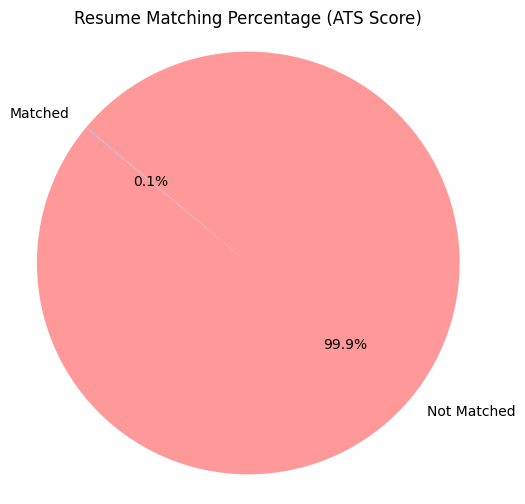

In [39]:

# Plot the pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Resume Matching Percentage (ATS Score)')
plt.axis('equal')  # Ensures the pie chart is circular
plt.show()


In [40]:

print("Matched Resumes Details (ATS Score >= 90%):\n")
for idx, score in enumerate(ats_scores):
    if score >= threshold:
        print(f"Resume {idx+1}: ATS Score: {score:.2f}%")
        print("Tokens Text:")
        print(resumes[idx])
        print("-" * 80)

Matched Resumes Details (ATS Score >= 90%):

Resume 1: ATS Score: 100.00%
Tokens Text:
['area', 'interest', 'deep', 'learn', 'control', 'system', 'design', 'program', 'inpython', 'electr', 'machineri', 'web', 'develop', 'analyt', 'technic', 'activ', 'q', 'hindustan', 'aeronaut', 'limit', 'bangalor', 'week', 'guidanc', 'mr', 'satish', 'senior', 'engin', 'hangar', 'mirag', 'fighter', 'aircraft', 'technic', 'skill', 'program', 'matlab', 'python', 'java', 'labview', 'python', 'webframeworkdjango', 'flask', 'ltspiceintermedi', 'languag', 'mipowerintermedi', 'github', 'gitbash', 'jupyt', 'notebook', 'xampp', 'mysqlbas', 'python', 'softwar', 'packag', 'interpretersanaconda', 'python', 'python', 'pycharm', 'java', 'ideeclips', 'oper', 'system', 'window', 'ubuntu', 'debiankali', 'linux', 'educ', 'detail', 'januari', 'btech', 'electr', 'electron', 'engin', 'manip', 'institut', 'technolog', 'januari', 'deeksha', 'center', 'januari', 'littl', 'flower', 'public', 'school', 'august', 'manip', 'acade